In [1]:
# Display tools
from IPython.display import HTML, display  # For HTML rendering in notebooks
import os 
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import tensorflow as tf

In [3]:
import matplotlib.pyplot as plt

def plot_score(hist):
    fig, ax = plt.subplots(5, 1, figsize=(10, 20))  # Corrected 'subplot' to 'subplots'
    ax = ax.ravel()

    for i, met in enumerate(['accuracy', 'precision', 'recall', 'AUC', 'loss']):
        ax[i].plot(hist.history[met])
        ax[i].plot(hist.history['val_' + met])
        ax[i].set_title(f'Model {met}')
        ax[i].set_xlabel('Epochs')
        ax[i].set_ylabel(met)
        ax[i].legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.show()


In [4]:
import os
import numpy as np

# Set directory where .npy files are stored
npy_dir = 'npy_data'

# Load preprocessed datasets
train_X_rgb = np.load(os.path.join(npy_dir, 'train_X_rgb.npy'))
train_Y     = np.load(os.path.join(npy_dir, 'train_Y.npy'))
test_X_rgb  = np.load(os.path.join(npy_dir, 'test_X_rgb.npy'))
test_Y      = np.load(os.path.join(npy_dir, 'test_Y.npy'))

In [5]:
# If not already defined earlier, calculate class weights again:
import pandas as pd

labels = pd.read_csv(r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_labels.csv")
count_normal = (labels['Target'] == 0).sum()
count_pneumonia = (labels['Target'] == 1).sum()
train_count = len(train_X_rgb)

classweight = {
    0: (1 / count_normal) * (train_count / 2.0),
    1: (1 / count_pneumonia) * (train_count / 2.0)
}

In [6]:
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras import Model


In [7]:
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='AUC'),
    tf.keras.metrics.TruePositives(name='tp'),
    tf.keras.metrics.TrueNegatives(name='tn'),
    tf.keras.metrics.FalsePositives(name='fp'),
    tf.keras.metrics.FalseNegatives(name='fn'),
    tf.keras.metrics.SpecificityAtSensitivity(0.9, name='specificity_at_sens_90'),
    tf.keras.metrics.SensitivityAtSpecificity(0.9, name='sensitivity_at_spec_90'),
]

In [8]:
import tensorflow as tf

# Flexible Exponential Decay Function
def get_exponential_decay_fn(lr_initial=0.01, decay_steps=20, decay_rate=0.1):
    """
    Returns a learning rate function using exponential decay.
    """
    return lambda epoch: lr_initial * decay_rate ** (epoch / decay_steps)

# Returns a LearningRateScheduler callback with decay configuration
def get_lr_scheduler_cb(lr_initial=0.01, decay_steps=20, decay_rate=0.1):
    return tf.keras.callbacks.LearningRateScheduler(
        schedule=get_exponential_decay_fn(lr_initial, decay_steps, decay_rate),
        verbose=1
    )

# Returns a ModelCheckpoint callback that saves to a unique file
def get_model_checkpoint_cb(model_name):
    return tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{model_name}.h5",
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1
    )

# Shared EarlyStopping callback
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Build Refined MobileNetV2 Model
def build_mn_model(input_shape=(64, 64, 3), fine_tune_at=None):
    inputs = Input(shape=input_shape)
    x = tf.keras.layers.Lambda(preprocess_input)(inputs)

    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )
    base_model.trainable = False

    # Enable fine-tuning if specified
    if fine_tune_at is not None:
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model



In [10]:
# Instantiate and Compile
mobilenet_model = build_mn_model(input_shape=(64, 64, 3), fine_tune_at=None)
mobilenet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=METRICS)
mobilenet_model.summary()

C:\Users\samya\AppData\Local\Temp\ipykernel_2896\1838461679.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64, 64, 3) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ lambda[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                 

 Total params: 2,345,153 (8.95 MB)

 Trainable params: 84,609 (330.50 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
checkpoint_cb = get_model_checkpoint_cb("mobilenet_model")
lr_scheduler_cb = get_lr_scheduler_cb()

In [12]:
# Train the CNN model with validation split and callbacks, no data shuffling
history_mn = mobilenet_model.fit(
    x=train_X_rgb,
    y=train_Y,
    epochs=50,
    batch_size=128,
    validation_split=0.15,
    class_weight=classweight,
    callbacks=[
        checkpoint_cb,         # Saves best model based on val_loss
        early_stopping_cb,     # Stops early if no val_loss improvement
        lr_scheduler_cb        # Adjusts learning rate over epochs
    ],
    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - AUC: 0.9041 - accuracy: 0.8162 - fn: 490.1011 - fp: 1354.6854 - loss: 0.3765 - precision: 0.7882 - recall: 0.9079 - sensitivity_at_spec_90: 0.7427 - specificity_at_sens_90: 0.7302 - tn: 3864.0337 - tp: 5746.6011
Epoch 1: val_loss improved from inf to 2.78231, saving model to mobilenet_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 383ms/step - AUC: 0.9043 - accuracy: 0.8164 - fn: 492.2737 - fp: 1360.4749 - loss: 0.3761 - precision: 0.7884 - recall: 0.9080 - sensitivity_at_spec_90: 0.7432 - specificity_at_sens_90: 0.7307 - tn: 3887.0278 - tp: 5778.3574 - val_AUC: 0.6301 - val_accuracy: 0.5503 - val_fn: 0.0000e+00 - val_fp: 1800.0000 - val_loss: 2.7823 - val_precision: 0.5501 - val_recall: 1.0000 - val_sensitivity_at_spec_90: 0.0000e+00 - val_specificity_at_sens_90: 0.2664 - val_tn: 2.0000 - val_tp: 2201.0000 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.008912509381337455.
Epoch 2/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - AUC: 0.9541 - accuracy: 0.8717 - fn: 360.8652 - fp: 1032.8033 - loss: 0.2592 - precision: 0.8387 - recall: 0.9418 - sensitivity_at_spec_90: 0.8712 - specificity_at_sens_90: 0.8740 - tn: 4254.0225 - tp: 5807.7305
Epoch 2: val_loss improved from 2.78231 to 0.46439, saving model to mobilenet_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 64s 358ms/step - AUC: 0.9541 - accuracy: 0.8717 - fn: 362.6704 - fp: 1037.8604 - loss: 0.2591 - precision: 0.8388 - recall: 0.9418 - sensitivity_at_spec_90: 0.8713 - specificity_at_sens_90: 0.8741 - tn: 4277.3687 - tp: 5840.2349 - val_AUC: 0.9434 - val_accuracy: 0.8179 - val_fn: 71.0000 - val_fp: 658.0000 - val_loss: 0.4644 - val_precision: 0.7640 - val_recall: 0.9677 - val_sensitivity_at_spec_90: 0.8174 - val_specificity_at_sens_90: 0.8024 - val_tn: 1144.0000 - val_tp: 2130.0000 - learning_rate: 0.0089

Epoch 3: LearningRateScheduler setting learning rate to 0.007943282347242816.
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - AUC: 0.9652 - accuracy: 0.8955 - fn: 341.9719 - fp: 860.1348 - loss: 0.2257 - precision: 0.8736 - recall: 0.9433 - sensitivity_at_spec_90: 0.9062 - specificity_at_sens_90: 0.9069 - tn: 4394.2358 - tp: 5859.0786
Epoch 3: val_loss improved from 0.46439 to 0.22182, saving model to mobilenet_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 64s 360ms/step - AUC: 0.9652 - accuracy: 0.8955 - fn: 343.7598 - fp: 864.8939 - loss: 0.2257 - precision: 0.8736 - recall: 0.9433 - sensitivity_at_spec_90: 0.9062 - specificity_at_sens_90: 0.9069 - tn: 4418.0615 - tp: 5891.4189 - val_AUC: 0.9784 - val_accuracy: 0.9138 - val_fn: 73.0000 - val_fp: 272.0000 - val_loss: 0.2218 - val_precision: 0.8867 - val_recall: 0.9668 - val_sensitivity_at_spec_90: 0.9391 - val_specificity_at_sens_90: 0.9451 - val_tn: 1530.0000 - val_tp: 2128.0000 - learning_rate: 0.0079

Epoch 4: LearningRateScheduler setting learning rate to 0.0070794578438413795.
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - AUC: 0.9668 - accuracy: 0.8979 - fn: 303.4157 - fp: 848.4213 - loss: 0.2187 - precision: 0.8707 - recall: 0.9522 - sensitivity_at_spec_90: 0.9091 - specificity_at_sens_90: 0.9097 - tn: 4414.0620 - tp: 5889.5225
Epoch 4: val_loss improved from 0.22182 to 0.19953, saving model to mobilenet_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 65s 366ms/step - AUC: 0.9668 - accuracy: 0.8979 - fn: 305.2458 - fp: 852.8101 - loss: 0.2187 - precision: 0.8707 - recall: 0.9522 - sensitivity_at_spec_90: 0.9091 - specificity_at_sens_90: 0.9097 - tn: 4438.2124 - tp: 5921.8657 - val_AUC: 0.9842 - val_accuracy: 0.9193 - val_fn: 45.0000 - val_fp: 278.0000 - val_loss: 0.1995 - val_precision: 0.8858 - val_recall: 0.9796 - val_sensitivity_at_spec_90: 0.9650 - val_specificity_at_sens_90: 0.9756 - val_tn: 1524.0000 - val_tp: 2156.0000 - learning_rate: 0.0071

Epoch 5: LearningRateScheduler setting learning rate to 0.006309573444801933.
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - AUC: 0.9685 - accuracy: 0.9022 - fn: 292.9888 - fp: 819.0000 - loss: 0.2125 - precision: 0.8778 - recall: 0.9543 - sensitivity_at_spec_90: 0.9234 - specificity_at_sens_90: 0.9235 - tn: 4372.5674 - tp: 5970.8652
Epoch 5: val_loss improved from 0.19953 to 0.18332, saving model to mobilenet_model.h5


...

178/178 ━━━━━━━━━━━━━━━━━━━━ 69s 385ms/step - AUC: 0.9761 - accuracy: 0.9148 - fn: 271.3687 - fp: 695.1285 - loss: 0.1861 - precision: 0.8935 - recall: 0.9554 - sensitivity_at_spec_90: 0.9408 - specificity_at_sens_90: 0.9405 - tn: 4599.6201 - tp: 5952.0166 - val_AUC: 0.9878 - val_accuracy: 0.9420 - val_fn: 72.0000 - val_fp: 160.0000 - val_loss: 0.1480 - val_precision: 0.9301 - val_recall: 0.9673 - val_sensitivity_at_spec_90: 0.9700 - val_specificity_at_sens_90: 0.9800 - val_tn: 1642.0000 - val_tp: 2129.0000 - learning_rate: 0.0032

Epoch 12: LearningRateScheduler setting learning rate to 0.002818382931264454.
Epoch 12/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - AUC: 0.9761 - accuracy: 0.9189 - fn: 263.6348 - fp: 669.0056 - loss: 0.1844 - precision: 0.9014 - recall: 0.9557 - sensitivity_at_spec_90: 0.9441 - specificity_at_sens_90: 0.9407 - tn: 4560.9214 - tp: 5961.8594
Epoch 12: val_loss did not improve from 0.14799
178/178 ━━━━━━━━━━━━━━━━━━━━ 68s 383ms/step - AUC: 0.9761 - accurac

178/178 ━━━━━━━━━━━━━━━━━━━━ 67s 375ms/step - AUC: 0.9772 - accuracy: 0.9206 - fn: 258.3352 - fp: 658.7039 - loss: 0.1804 - precision: 0.9018 - recall: 0.9567 - sensitivity_at_spec_90: 0.9461 - specificity_at_sens_90: 0.9476 - tn: 4633.7598 - tp: 5967.3350 - val_AUC: 0.9888 - val_accuracy: 0.9463 - val_fn: 70.0000 - val_fp: 145.0000 - val_loss: 0.1436 - val_precision: 0.9363 - val_recall: 0.9682 - val_sensitivity_at_spec_90: 0.9759 - val_specificity_at_sens_90: 0.9839 - val_tn: 1657.0000 - val_tp: 2131.0000 - learning_rate: 0.0022

Epoch 15: LearningRateScheduler setting learning rate to 0.0019952623149688802.
Epoch 15/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - AUC: 0.9776 - accuracy: 0.9220 - fn: 255.4270 - fp: 642.1517 - loss: 0.1776 - precision: 0.9045 - recall: 0.9584 - sensitivity_at_spec_90: 0.9489 - specificity_at_sens_90: 0.9484 - tn: 4578.1685 - tp: 5979.6743
Epoch 15: val_loss improved from 0.14355 to 0.13892, saving model to mobilenet_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 69s 386ms/step - AUC: 0.9776 - accuracy: 0.9220 - fn: 256.7709 - fp: 645.7709 - loss: 0.1776 - precision: 0.9045 - recall: 0.9584 - sensitivity_at_spec_90: 0.9489 - specificity_at_sens_90: 0.9484 - tn: 4603.3242 - tp: 6012.2681 - val_AUC: 0.9892 - val_accuracy: 0.9510 - val_fn: 60.0000 - val_fp: 136.0000 - val_loss: 0.1389 - val_precision: 0.9403 - val_recall: 0.9727 - val_sensitivity_at_spec_90: 0.9777 - val_specificity_at_sens_90: 0.9850 - val_tn: 1666.0000 - val_tp: 2141.0000 - learning_rate: 0.0020

Epoch 16: LearningRateScheduler setting learning rate to 0.001778279410038923.
Epoch 16/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - AUC: 0.9794 - accuracy: 0.9218 - fn: 259.0955 - fp: 641.6124 - loss: 0.1701 - precision: 0.9026 - recall: 0.9586 - sensitivity_at_spec_90: 0.9518 - specificity_at_sens_90: 0.9565 - tn: 4603.9214 - tp: 5950.7920
Epoch 16: val_loss did not improve from 0.13892
178/178 ━━━━━━━━━━━━━━━━━━━━ 68s 383ms/step - AUC: 0.9793 - accurac

178/178 ━━━━━━━━━━━━━━━━━━━━ 65s 367ms/step - AUC: 0.9781 - accuracy: 0.9234 - fn: 249.5698 - fp: 629.2458 - loss: 0.1763 - precision: 0.9043 - recall: 0.9595 - sensitivity_at_spec_90: 0.9528 - specificity_at_sens_90: 0.9518 - tn: 4654.7822 - tp: 5984.5361 - val_AUC: 0.9895 - val_accuracy: 0.9488 - val_fn: 55.0000 - val_fp: 150.0000 - val_loss: 0.1375 - val_precision: 0.9347 - val_recall: 0.9750 - val_sensitivity_at_spec_90: 0.9773 - val_specificity_at_sens_90: 0.9872 - val_tn: 1652.0000 - val_tp: 2146.0000 - learning_rate: 0.0013

Epoch 20: LearningRateScheduler setting learning rate to 0.0011220184543019637.
Epoch 20/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - AUC: 0.9801 - accuracy: 0.9235 - fn: 240.9045 - fp: 631.4269 - loss: 0.1672 - precision: 0.9027 - recall: 0.9621 - sensitivity_at_spec_90: 0.9539 - specificity_at_sens_90: 0.9573 - tn: 4627.1294 - tp: 5955.9604
Epoch 20: val_loss improved from 0.13745 to 0.13629, saving model to mobilenet_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 73s 410ms/step - AUC: 0.9801 - accuracy: 0.9235 - fn: 242.2179 - fp: 634.9218 - loss: 0.1672 - precision: 0.9027 - recall: 0.9621 - sensitivity_at_spec_90: 0.9539 - specificity_at_sens_90: 0.9573 - tn: 4652.1953 - tp: 5988.7988 - val_AUC: 0.9895 - val_accuracy: 0.9495 - val_fn: 55.0000 - val_fp: 147.0000 - val_loss: 0.1363 - val_precision: 0.9359 - val_recall: 0.9750 - val_sensitivity_at_spec_90: 0.9777 - val_specificity_at_sens_90: 0.9861 - val_tn: 1655.0000 - val_tp: 2146.0000 - learning_rate: 0.0011

Epoch 21: LearningRateScheduler setting learning rate to 0.001.
Epoch 21/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - AUC: 0.9804 - accuracy: 0.9279 - fn: 230.8483 - fp: 603.5562 - loss: 0.1658 - precision: 0.9085 - recall: 0.9642 - sensitivity_at_spec_90: 0.9562 - specificity_at_sens_90: 0.9530 - tn: 4638.1182 - tp: 5982.8989
Epoch 21: val_loss did not improve from 0.13629
178/178 ━━━━━━━━━━━━━━━━━━━━ 68s 384ms/step - AUC: 0.9804 - accuracy: 0.9279 - fn:

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - AUC: 0.9870 - accuracy: 0.9474 - fn: 20.9053 - fp: 59.2842 - loss: 0.1590 - precision: 0.9300 - recall: 0.9742 - sensitivity_at_spec_90: 0.9766 - specificity_at_sens_90: 0.9875 - tn: 657.7263 - tp: 797.5789

Evaluation Results:
                 AUC: 0.9882
            accuracy: 0.9487
                  fn: 37.0000
                  fp: 117.0000
                loss: 0.1485
           precision: 0.9311
              recall: 0.9771
sensitivity_at_spec_90: 0.9802
specificity_at_sens_90: 0.9826
                  tn: 1265.0000
                  tp: 1581.0000


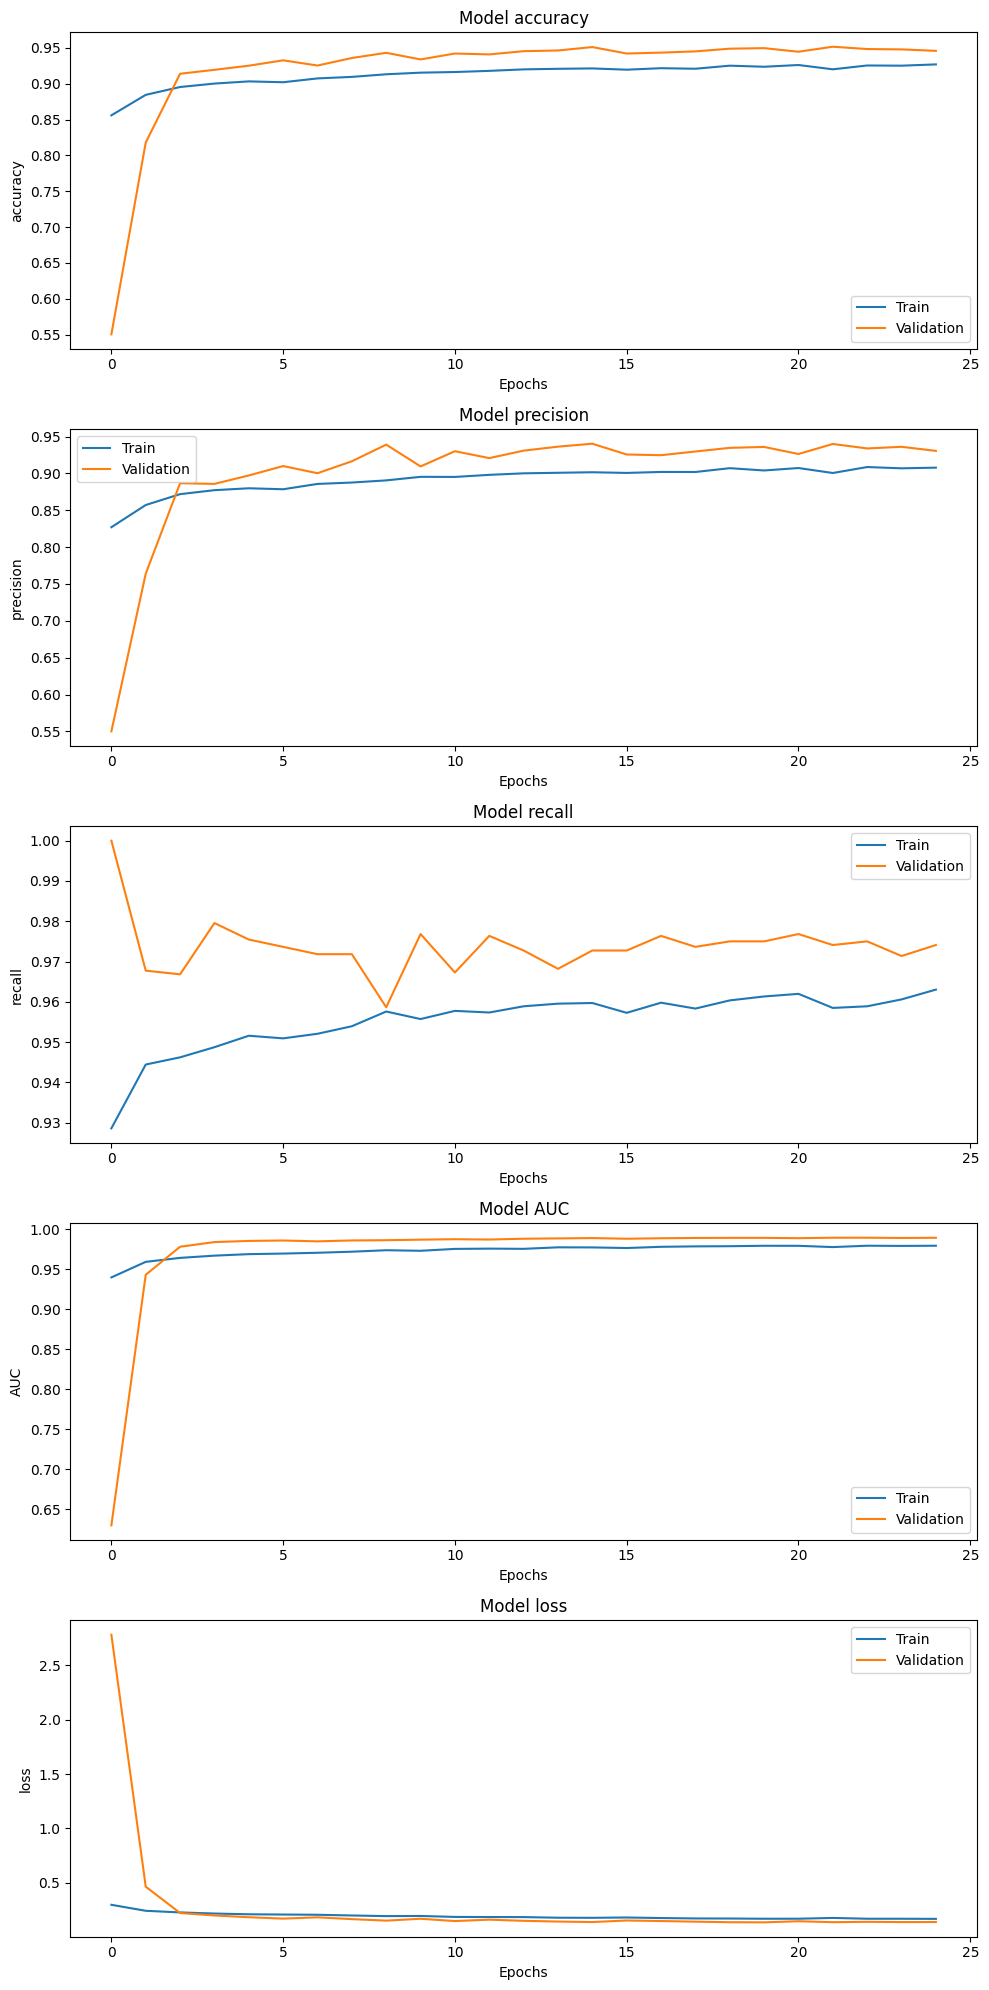

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step

Confusion Matrix:
[[1265  117]
 [  37 1581]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9716    0.9153    0.9426      1382
           1     0.9311    0.9771    0.9536      1618

    accuracy                         0.9487      3000
   macro avg     0.9513    0.9462    0.9481      3000
weighted avg     0.9497    0.9487    0.9485      3000



In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Evaluate the trained model on the test dataset and return results as a dictionary
results = mobilenet_model.evaluate(test_X_rgb, test_Y, return_dict=True)

# Display evaluation metrics in a readable format
print("\nEvaluation Results:")
for metric, value in results.items():
    print(f"{metric:>20}: {value:.4f}")

# Plot training and validation metrics (assumes 'plot_score' is a custom function)
plot_score(history_mn)

# Predict probabilities on the test set
pred_probs = mobilenet_model.predict(test_X_rgb)

# Convert predicted probabilities to binary class labels (threshold = 0.5)
pred_labels = (pred_probs > 0.5).astype("int32")

# Generate and print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(test_Y, pred_labels))

# Print detailed classification report (precision, recall, F1, etc.)
print("\nClassification Report:")
print(classification_report(test_Y, pred_labels, digits=4))